In [1]:
from pathlib import Path 
data_dir = Path(r"F:\Computer Vision\Test images for computer vision code")
image_files = sorted(data_dir.glob('*.tif')) + sorted(data_dir.glob('*.png')) + sorted(data_dir.glob('*.jpg')) 
print(f"Found {len(image_files)} images") 
print(image_files[:5])

Found 31 images
[WindowsPath('F:/Computer Vision/Test images for computer vision code/Img000000.tif'), WindowsPath('F:/Computer Vision/Test images for computer vision code/Img000001.tif'), WindowsPath('F:/Computer Vision/Test images for computer vision code/Img000002.tif'), WindowsPath('F:/Computer Vision/Test images for computer vision code/Img000003.tif'), WindowsPath('F:/Computer Vision/Test images for computer vision code/Img000004.tif')]


In [2]:
import matplotlib.pyplot as plt 
import matplotlib.image as mpimg 
first_image = mpimg.imread(image_files[0]) 
print(first_image.shape) 
print(first_image.dtype)

(656, 1280, 3)
uint8


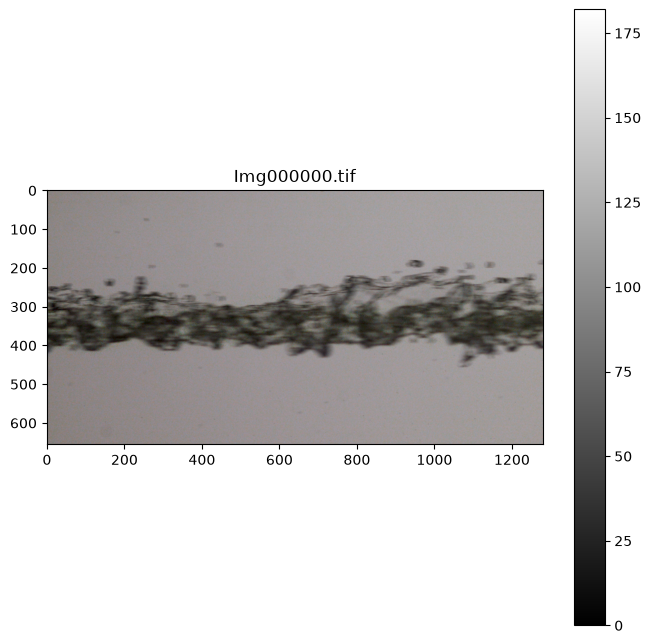

In [3]:
plt.figure(figsize=(8, 8)) 
plt.imshow(first_image, cmap='gray') 
plt.title(image_files[0].name) 
plt.colorbar() 
plt.show()

In [4]:
red_channel = first_image[:, :, 0] 
print(red_channel.shape) 
print(red_channel.min(), red_channel.max(), red_channel.mean())

(656, 1280)
0 182 137.6555020960366


In [5]:
threshold = 90
binary = red_channel < threshold 
print(binary.dtype) 
print(binary.sum(), "pixels classified as foreground")

bool
119927 pixels classified as foreground


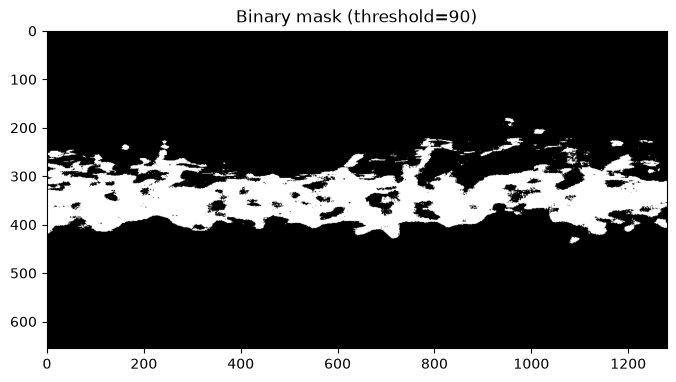

In [6]:
plt.figure(figsize=(8, 8)) 
plt.imshow(binary, cmap='gray') 
plt.title(f"Binary mask (threshold={threshold})") 
plt.show()

In [7]:
from scipy import ndimage

labeled_array, num_features = ndimage.label(binary)
print(f"Found {num_features} separate connected regions")

Found 425 separate connected regions


In [8]:
sizes = ndimage.sum(binary, labeled_array, range(1, num_features + 1))
print(sizes)

[1.1000e+02 1.0000e+00 3.3000e+01 1.0000e+00 1.0000e+00 1.7400e+02
 5.4500e+02 1.1333e+05 7.0000e+00 4.0000e+00 9.0000e+00 1.0000e+00
 4.3000e+01 2.4300e+02 7.8000e+01 2.0000e+00 1.0000e+00 2.4000e+01
 1.0000e+00 2.0000e+00 1.0000e+00 2.0000e+00 1.0000e+00 1.0300e+02
 1.2800e+02 1.2000e+01 8.0000e+01 1.0000e+00 1.0000e+00 1.0000e+00
 2.0000e+00 1.0000e+00 1.8700e+02 1.0000e+00 1.0000e+00 1.0000e+00
 2.0000e+00 1.0000e+00 3.0000e+00 2.0000e+00 5.0000e+00 5.0800e+02
 1.3000e+01 2.0000e+00 2.0000e+00 1.0000e+00 1.0000e+00 2.0000e+00
 1.1900e+02 1.0000e+00 5.6000e+01 1.5000e+01 7.0000e+00 1.0000e+00
 2.0000e+00 1.0000e+00 2.0000e+00 1.0000e+00 1.0000e+00 3.3000e+01
 1.0000e+00 2.0000e+00 1.0000e+00 4.0000e+00 9.0000e+00 7.4500e+02
 1.5000e+01 1.0000e+00 1.0000e+00 1.0000e+00 5.0000e+00 3.0000e+00
 1.0000e+00 2.8000e+01 1.0000e+00 3.0000e+00 1.3000e+01 1.0000e+01
 1.0000e+00 1.0000e+00 1.0000e+00 1.0000e+00 2.0000e+00 1.0000e+00
 1.0000e+00 1.2400e+02 1.0000e+00 1.0000e+00 7.5000e+01 1.2000

In [9]:
import numpy as np

sizes_sorted = np.sort(sizes)[::-1]
print("Largest 10 blobs:", sizes_sorted[:10])
print("Smallest 10 blobs:", sizes_sorted[-10:])

Largest 10 blobs: [113330.    745.    545.    508.    312.    281.    243.    226.    219.
    187.]
Smallest 10 blobs: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [10]:
min_area = 5 
max_area = 2500 
valid_labels = [i + 1 for i, size in enumerate(sizes) if min_area <= size <= max_area] 
print(f"{len(valid_labels)} blobs pass the size filter (out of {num_features} total)")

90 blobs pass the size filter (out of 425 total)


In [11]:
valid_sizes = [sizes[i - 1] for i in valid_labels] 
print(sorted(valid_sizes, reverse=True))

[np.float64(745.0), np.float64(545.0), np.float64(508.0), np.float64(312.0), np.float64(281.0), np.float64(243.0), np.float64(226.0), np.float64(219.0), np.float64(187.0), np.float64(174.0), np.float64(170.0), np.float64(128.0), np.float64(124.0), np.float64(119.0), np.float64(111.0), np.float64(110.0), np.float64(109.0), np.float64(103.0), np.float64(97.0), np.float64(82.0), np.float64(81.0), np.float64(80.0), np.float64(78.0), np.float64(75.0), np.float64(75.0), np.float64(67.0), np.float64(67.0), np.float64(66.0), np.float64(56.0), np.float64(53.0), np.float64(50.0), np.float64(43.0), np.float64(40.0), np.float64(36.0), np.float64(34.0), np.float64(33.0), np.float64(33.0), np.float64(28.0), np.float64(25.0), np.float64(24.0), np.float64(23.0), np.float64(17.0), np.float64(15.0), np.float64(15.0), np.float64(15.0), np.float64(15.0), np.float64(13.0), np.float64(13.0), np.float64(13.0), np.float64(12.0), np.float64(12.0), np.float64(11.0), np.float64(10.0), np.float64(10.0), np.float6

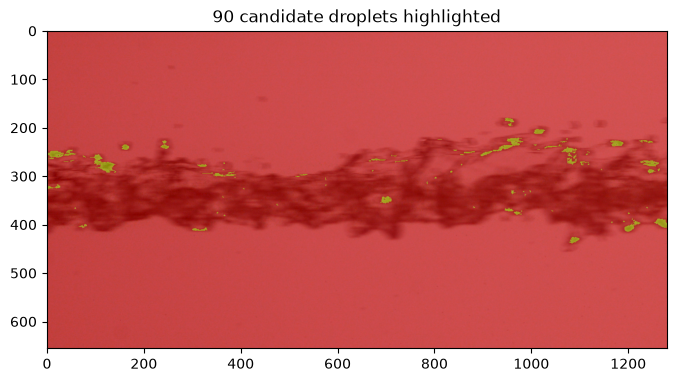

In [12]:
import matplotlib.pyplot as plt 
import numpy as np 
mask_filtered = np.isin(labeled_array, valid_labels) 
plt.figure(figsize=(8, 8)) 
plt.imshow(first_image) 
plt.imshow(mask_filtered, cmap='autumn', alpha=0.5) 
plt.title(f"{len(valid_labels)} candidate droplets highlighted") 
plt.show()

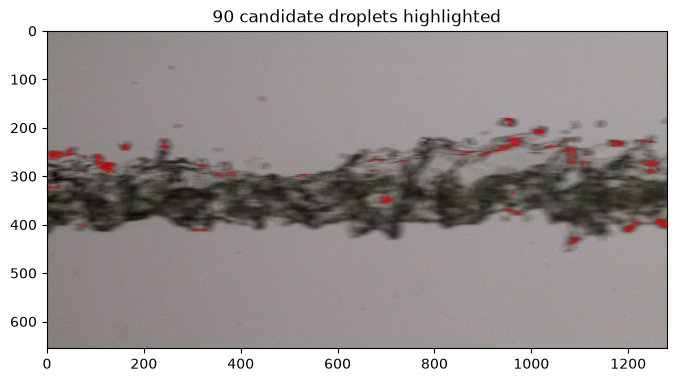

In [13]:
import numpy.ma as ma
masked_overlay = ma.masked_where(~mask_filtered, mask_filtered)
plt.figure(figsize=(8, 8))
plt.imshow(first_image)
plt.imshow(masked_overlay, cmap="autumn", alpha=0.6)
plt.title(f"{len(valid_labels)} candidate droplets highlighted")
plt.show()

In [14]:
from scipy import ndimage as ndi

structure = np.array([[0, 1, 0], [1, 1, 1], [0, 1, 0]])

binary_closed = ndi.binary_closing(binary, structure=structure)

labeled_closed, num_closed = ndi.label(binary_closed)
sizes_closed = ndi.sum(binary_closed, labeled_closed, range(1, num_closed + 1))

valid_labels_closed = [
    i + 1 for i, size in enumerate(sizes_closed) if min_area <= size <= max_area
]
print(
    f"{len(valid_labels_closed)} blobs pass the filter after closing (previously {len(valid_labels)})"
)

51 blobs pass the filter after closing (previously 90)


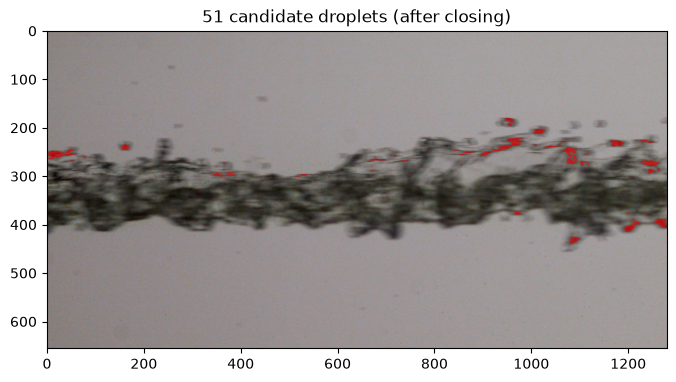

In [15]:
mask_filtered_closed = np.isin(labeled_closed, valid_labels_closed)
masked_overlay_closed = ma.masked_where(~mask_filtered_closed, mask_filtered_closed)

plt.figure(figsize=(8, 8))
plt.imshow(first_image)
plt.imshow(masked_overlay_closed, cmap="autumn", alpha=0.6)
plt.title(f"{len(valid_labels_closed)} candidate droplets (after closing)")
plt.show()

In [16]:
binary_opened = ndi.binary_opening(binary, structure=structure) 
labeled_opened, num_opened = ndi.label(binary_opened) 
sizes_opened = ndi.sum(binary_opened, labeled_opened, range(1, num_opened + 1)) 
valid_labels_opened = [i + 1 for i, size in enumerate(sizes_opened) if min_area <= size <= max_area] 
print(f"{len(valid_labels_opened)} blobs pass the filter after OPENING (closing gave {len(valid_labels_closed)}, raw gave {len(valid_labels)})")

85 blobs pass the filter after OPENING (closing gave 51, raw gave 90)


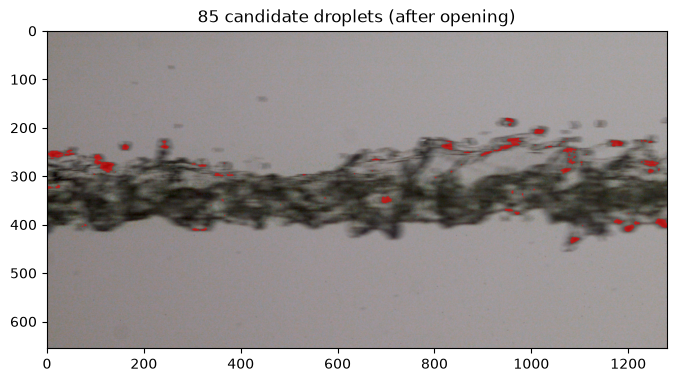

In [17]:
mask_filtered_opened = np.isin(labeled_opened, valid_labels_opened) 
masked_overlay_opened = ma.masked_where(~mask_filtered_opened, mask_filtered_opened) 
plt.figure(figsize=(8, 8)) 
plt.imshow(first_image) 
plt.imshow(masked_overlay_opened, cmap="autumn", alpha=0.6) 
plt.title(f"{len(valid_labels_opened)} candidate droplets (after opening)") 
plt.show()

In [18]:
for n in [1, 2, 3, 5]:
    binary_test = ndi.binary_opening(binary, structure=structure, iterations=n)
    labeled_test, num_test = ndi.label(binary_test)
    sizes_test = ndi.sum(binary_test, labeled_test, range(1, num_test + 1))
    valid_test = [
        i + 1 for i, size in enumerate(sizes_test) if min_area <= size <= max_area
    ]
    print(f"iterations={n}: {len(valid_test)} blobs pass filter")

iterations=1: 85 blobs pass filter
iterations=2: 44 blobs pass filter
iterations=3: 36 blobs pass filter
iterations=5: 23 blobs pass filter


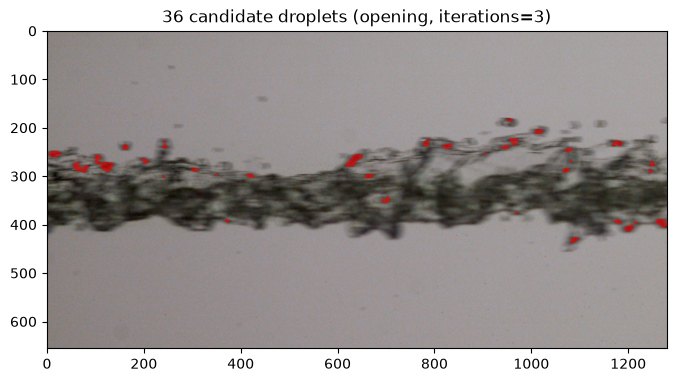

In [19]:
binary_opened3 = ndi.binary_opening(binary, structure=structure, iterations=3)
labeled_opened3, num_opened3 = ndi.label(binary_opened3)
sizes_opened3 = ndi.sum(binary_opened3, labeled_opened3, range(1, num_opened3 + 1))
valid_labels_opened3 = [
    i + 1 for i, size in enumerate(sizes_opened3) if min_area <= size <= max_area
]

mask_filtered3 = np.isin(labeled_opened3, valid_labels_opened3)
masked_overlay3 = ma.masked_where(~mask_filtered3, mask_filtered3)

plt.figure(figsize=(8, 8))
plt.imshow(first_image)
plt.imshow(masked_overlay3, cmap="autumn", alpha=0.6)
plt.title(f"{len(valid_labels_opened3)} candidate droplets (opening, iterations=3)")
plt.show()

In [20]:
hx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]) 
hy = hx.T 
Gx = ndi.convolve(red_channel.astype(float), hx) 
Gy = ndi.convolve(red_channel.astype(float), hy) 
grad_mag = np.sqrt(Gx**2 + Gy**2) 
print(grad_mag.shape, grad_mag.min(), grad_mag.max())

(656, 1280) 0.0 379.5813483299726


In [21]:
sharp_limit = 15

final_valid_labels = []
for lbl in valid_labels_opened3:
    blob_mask = labeled_opened3 == lbl
    boundary = blob_mask & ~ndi.binary_erosion(blob_mask)
    mean_edge_grad = grad_mag[boundary].mean()
    if mean_edge_grad >= sharp_limit:
        final_valid_labels.append(lbl)

print(
    f"{len(final_valid_labels)} blobs pass size AND sharpness filter (had {len(valid_labels_opened3)} after size-only)"
)

36 blobs pass size AND sharpness filter (had 36 after size-only)


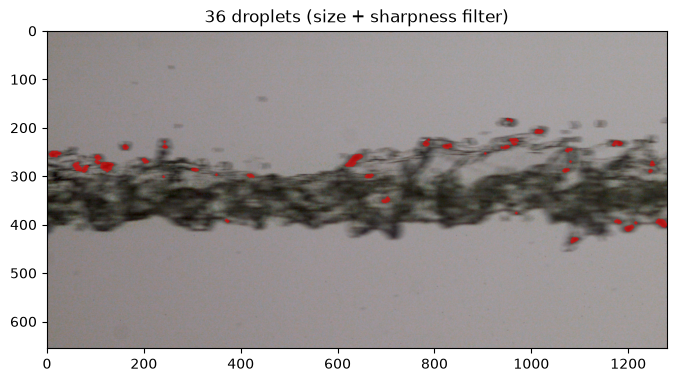

In [22]:
final_mask = np.isin(labeled_opened3, final_valid_labels) 
final_overlay = ma.masked_where(~final_mask, final_mask) 
plt.figure(figsize=(8, 8)) 
plt.imshow(first_image) 
plt.imshow(final_overlay, cmap='autumn', alpha=0.6) 
plt.title(f"{len(final_valid_labels)} droplets (size + sharpness filter)") 
plt.show() 

In [23]:
print(first_image.shape)
print(red_channel.shape)
print(grad_mag.shape)
print(image_files[0])

(656, 1280, 3)
(656, 1280)
(656, 1280)
F:\Computer Vision\Test images for computer vision code\Img000000.tif


In [24]:
def process_frame(filepath, threshold=110, min_area=5, max_area=2500): 
    img = mpimg.imread(filepath) 
    red = img[:, :, 0] 
    binary = red < threshold 
    labeled, num = ndi.label(binary) 
    sizes = ndi.sum(binary, labeled, range(1, num + 1)) 
    valid = [i + 1 for i, s in enumerate(sizes) if min_area <= s <= max_area] 
    return { 'filename': filepath.name, 'num_droplets': len(valid), 'total_area': sum(sizes[i - 1] for i in valid), } 
test_result = process_frame(image_files[0]) 
print(test_result)

{'filename': 'Img000000.tif', 'num_droplets': 49, 'total_area': np.float64(4755.0)}


In [25]:
all_results = []
for filepath in image_files:
    result = process_frame(filepath)
    all_results.append(result)
    print(f"{result['filename']}: {result['num_droplets']} droplets")

print(f"\nTotal results collected: {len(all_results)}")

Img000000.tif: 49 droplets
Img000001.tif: 47 droplets
Img000002.tif: 44 droplets
Img000003.tif: 56 droplets
Img000004.tif: 46 droplets
Img000005.tif: 50 droplets
Img000006.tif: 66 droplets
Img000007.tif: 59 droplets
Img000008.tif: 67 droplets
Img000009.tif: 62 droplets
Img000010.tif: 66 droplets
Img000011.tif: 51 droplets
Img000012.tif: 71 droplets
Img000013.tif: 70 droplets
Img000014.tif: 71 droplets
Img000015.tif: 75 droplets
Img000016.tif: 60 droplets
Img000017.tif: 41 droplets
Img000018.tif: 42 droplets
Img000019.tif: 37 droplets
Img000020.tif: 59 droplets
Img000021.tif: 60 droplets
Img000022.tif: 52 droplets
Img000023.tif: 56 droplets
Img000024.tif: 57 droplets
Img000025.tif: 46 droplets
Img000026.tif: 62 droplets
Img000027.tif: 77 droplets
Img000028.tif: 71 droplets
Img000029.tif: 69 droplets
Img000030.tif: 56 droplets

Total results collected: 31


In [26]:
import pandas as pd 
df_results = pd.DataFrame(all_results) 
print(df_results) 
df_results.to_csv('../data/droplet_counts_per_frame.csv', index=False)

         filename  num_droplets  total_area
0   Img000000.tif            49      4755.0
1   Img000001.tif            47      3957.0
2   Img000002.tif            44      4018.0
3   Img000003.tif            56      5349.0
4   Img000004.tif            46      3049.0
5   Img000005.tif            50      1914.0
6   Img000006.tif            66      4728.0
7   Img000007.tif            59      3674.0
8   Img000008.tif            67      5291.0
9   Img000009.tif            62      4607.0
10  Img000010.tif            66      4752.0
11  Img000011.tif            51      2880.0
12  Img000012.tif            71      8784.0
13  Img000013.tif            70      7011.0
14  Img000014.tif            71      4783.0
15  Img000015.tif            75      5323.0
16  Img000016.tif            60      2858.0
17  Img000017.tif            41      4544.0
18  Img000018.tif            42      2317.0
19  Img000019.tif            37      2533.0
20  Img000020.tif            59      4362.0
21  Img000021.tif            60 

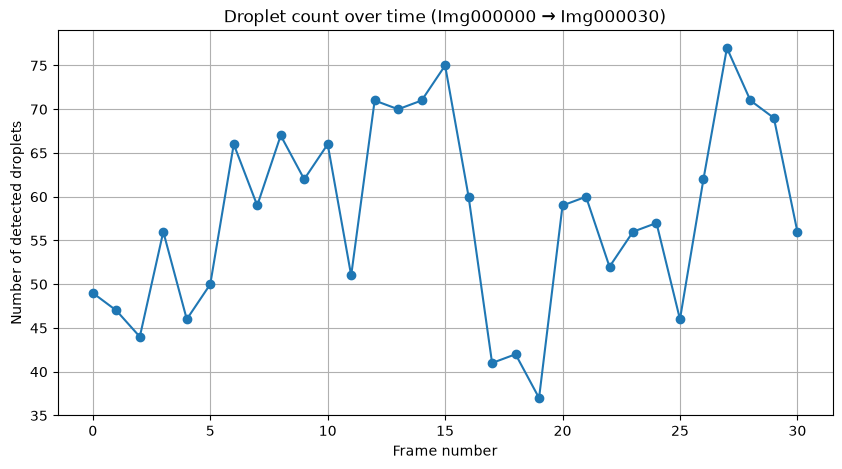

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(df_results["num_droplets"], marker="o")
plt.xlabel("Frame number")
plt.ylabel("Number of detected droplets")
plt.title("Droplet count over time (Img000000 → Img000030)")
plt.grid(True)
plt.show()

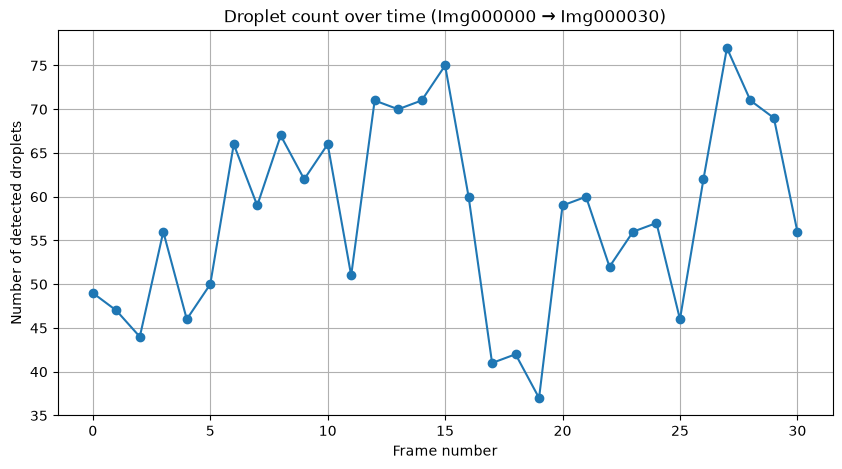

In [28]:
plt.figure(figsize=(10, 5)) 
plt.plot(df_results['num_droplets'], marker='o') 
plt.xlabel('Frame number') 
plt.ylabel('Number of detected droplets') 
plt.title('Droplet count over time (Img000000 → Img000030)') 
plt.grid(True) 
plt.savefig('../data/droplet_count_trend.png', dpi=150, bbox_inches='tight') 
plt.show()

In [29]:
a = pd.read_csv("../data/droplet_counts_per_frame.csv")
b = pd.read_csv("../data/results.csv")
print((a["num_droplets"] == b["num_droplets"]).all())
print((a["total_area"] == b["total_area"]).all())

True
True
